# Chapter 6: Function (part II)

In part I, we saw how functions can be used to reuse code, discussed arguments and return values.

The general definition of a function is something like:

``` 
def functionName(arg1: type1, arg2: type2, ...) -> returnType:
    '''
    documentation: at the very least, describe what the arguments 
    should be, what the return values are and how they are computed.
    This can span multiple lines
    '''
    <some python code here indented to the right of the 'def' statement>
    return <returnValue(s)>
```

Specifying the type of the arguments and return values (type hinting) is not technically mandatory 
but is considered good practice. We will systematically use type hints in this class.
Here is a list of standard python types and how they are to be used  for type hints:

### Basic types:
* `x: int = 1`
* `x: float = 1.0`
* `x: bool = True`
* `x: str = "test"`

### Containers:
* `x: list[int] = [1]`
* `x: set[int] = {6, 7}`
* `x: dict[str, float] = {"field": 2.0}`
*  tuples of fixed size
   `x: tuple[int, str, float] = (3, "yes", 7.5)`
* tuples of variable size
    `x: tuple[int, ...] = (1, 2, 3)`

### More advanced hints:
* use the `|` operator when something could be one of a few types `x: list[int | str] = [3, 5, "test", "fun"]`
* use `<X> | None` for something that could be of type `X` or nothing


In [2]:
# Going back to quadratic formula, the proper way to indicate types would be:

def quadraticSolve(a: float, b: float, c: float) -> tuple[float, float] | float | None:
    '''
    Compute the real roots of the quadratic equation ax^2 + bx + c = 0
    '''
    import math
    discriminant = b**2 - 4 * a * c
    if discriminant > 0:
        return (-b - math.sqrt(discriminant)) / 2 / a, (-b + math.sqrt(discriminant)) / 2 / a
    elif discriminant == 0:
        return -b / 2 / a
    else:
        print("This equation does not admit any real root")

roots = quadraticSolve(10,3,2)
print(roots)

This equation does not admit any real root
None


## 6.5 Scope
We saw that the arguments of a function only exist *inside* the function body. We say that the scope of the arguments is local to the function (or sometimes that they 'fall out of scope' outside of the function).

### Visibility and scope obey the following rules:
* The scope of any variable that is created *inside* a function is limited to the said function. We say that the variable is *local* to the function.

In [4]:
x = 12
def example1(y: int):
    z = 23
    # x is global, y and z are local
    print(f"inside example1: x = {x}, y = {y}, z = {z}")
example1(0)

inside example1: x = 12, y = 0, z = 23


* Any variable that is in the scope at the function call can be accessed but not modified. We say that these are *global* to the function
* If several variables with the same name exist, the one with the most local scope replaces the other ones.

In [7]:
x = 12
def example2(y: int):
    x = 100
    z = 23
    # x is now local, z is still global
    print(f"inside example2: x = {x}, y = {y}, z = {z}")
example2(0)
print(f"back in caller scope: x = {x}")

inside example2: x = 100, y = 0, z = 23
back in caller scope: x=12


In [10]:
x = 12
def example3(y: int):
    z = x # This implies that 'x' refers to a variable in the global context
    x = y # Global context variables cannot be modified
    print(f"inside example3: x = {x}, y = {y}, z = {z}")
example3(0)

UnboundLocalError: cannot access local variable 'x' where it is not associated with a value

In [12]:
x = 12
def example4(y: int):
    x = y # This implies that 'x' refers to a variable in the local context
    z = x 
    print(f"inside example4: x = {x}, y = {y}, z = {z}")
example4(0)
print(f"back in caller scope: x = {x}")

inside example4: x = 0, y = 0, z = 0
back in caller scope: x = 12


Things can get really complicated really quickly, for instance:

In [14]:
X = 1
y = 2
def f1():
    x = 12
    print(f'in f1: x = {x}, y = {y}')

def f2():
    y = 54
    print(f'in f2: x = {x}, y = {y}')
    f1()
f1()
f2()

in f1: x = 12, y = 2
in f2: x = 12, y = 54
in f1: x = 12, y = 2


The only way to maintain sanity is to avoid accessing global variables unless it is really impossible not to (which is very rare).
Instead, pass everything needed as arguments.

## 6.6 Side effects

> "A function is said to have a *side effects* if it has any observable effect other than its primary effect of reading the value of its arguments and returning a value to the invoker of the operation."

* We have seen that a python function cannot change variables outside its scope (see `example2` above).
* It also cannot change the value of its arguments. (this makes sense, since we can pass *constants* as arguments).

Summary, anything that you want modified in a function needs to be `return`ed

In [16]:
x = 1
y = 2
def example5(x,z):
    x = z
    print(f"inside example5: x = {x}, y = {y}")

print(f"before example5: x = {x}, y = {y}")
example5(x,y)
print(f"after example5:  x = {x}, y = {y}")

before example5: x = 1, y = 2
inside example5: x = 2, y = 2
after example5:  x = 1, y = 2


### Warning: things get more complicated with containers...


In [ ]:
X = [1,2,3]
Y = [4,5,6]
def example6(Z):
    X[1] = Z[1]
    print(f"inside example6: X = {X}, Z = {Z}")
print(f"before example6: X = {X}, Y = {Y}")
example6(Y)
print(f"after example6:  X = {X}, Y = {Y}")

How come X was changed inside `example6`???

In [18]:
X = [1,2,3]
Y = [4,5,6]
def example7(Z):
    X = Z
    print(f"inside example7: X = {X}, Z = {Z}")
print(f"before example7: X = {X}, Y = {Y}")
example7(Y)
print(f"after example7:  X = {X}, Y = {Y}")

before example7: X = [1, 2, 3], Y = [4, 5, 6]
inside example7: X = [4, 5, 6], Z = [4, 5, 6]
after example7:  X = [1, 2, 3], Y = [4, 5, 6]


How come X was changed inside `example6` but not inside `example7`???

## 6.7 lambda-functions
Lambdas are compact ways to define functions without necessarily giving them names. 

Syntax:
```
lambda arguments : expression
```

In [19]:
def evaluateat(f,x):
    print(f"f({x}) = {f(x)}")

def g(x):
    return x**2

evaluateat(g,4)
evaluateat(g,5)

f(4) = 16
f(5) = 25


say we just want to call `evaluateat` for $f(x) = x^2$ but will never really reuse $f$, so don't want to define this function. We can use a lambda here:

In [ ]:
evaluateat(lambda x : x**2, 10)

A classical use of lambdas is to fix some parameters of a function.
The function $f(x) = |x|$ is not differentiable at 0. It is common to approximate by
$$
    f_\varepsilon(x) \ \sqrt{x^2+ \varepsilon},
$$
where $0 <\varepsilon$ is a small regularization parameter.

Let's compare the values of $f$ and $f_\varepsilon$.

In [21]:
import math
def smoothabs(a,epsilon):
    return math.sqrt(a**2+epsilon)

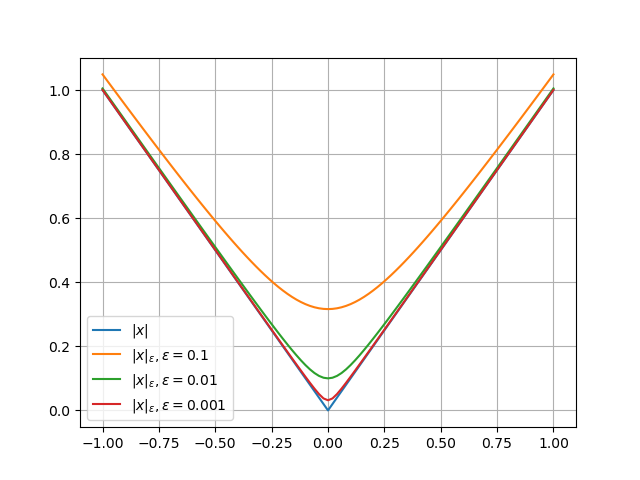

In [23]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
X = np.linspace(-1,1,101)

fig, ax = plt.subplots()
ax.plot(X,[abs(x) for x in X], label = f'$|x|$')
for epsilon in [0.1, 0.01, 0.001]:
    ax.plot(X,[smoothabs(x,epsilon) for x in X], label = f'$|x|_\\varepsilon, \\varepsilon = {{{epsilon}}}$')
ax.legend(loc=0)
ax.grid()

Another example: a function that 'tabulates' a mathematical function:

In [24]:
def tabulate (x,f):
    print("x:    ", end="")
    for xx in x:
        print(f"{xx:.3f}", end = "\t")
    print()
    print("f(x): ", end="")
    for xx in x:
        print(f"{f(xx):.3f}", end = "\t")
    print()

def g(y):
    return y**2

tabulate([1.,2.,3., 4.5], g)

x:    1.000	2.000	3.000	4.500	
f(x): 1.000	4.000	9.000	20.250	


In [25]:
X = [-1, -0.5, 0, 0.5, 1]
tabulate(X, lambda x: abs(x))
tabulate(X, lambda x : smoothabs(x, 0.001))

x:    -1.000	-0.500	0.000	0.500	1.000	
f(x): 1.000	0.500	0.000	0.500	1.000	
x:    -1.000	-0.500	0.000	0.500	1.000	
f(x): 1.000	0.501	0.032	0.501	1.000	


In [26]:
def derivate(f,a,h):
    return (f(a+h) - f(a))/h

def g(x):
    return x**2

tabulate(X,g)
tabulate(X, lambda x : derivate(g,x,0.001))

x:    -1.000	-0.500	0.000	0.500	1.000	
f(x): 1.000	0.250	0.000	0.250	1.000	
x:    -1.000	-0.500	0.000	0.500	1.000	
f(x): -1.999	-0.999	0.001	1.001	2.001	
